# Regresión One vs All de dataset no grafico

## Preparar datos

In [ ]:
# utilizado para la manipulación de directorios y rutas
import os

# Cálculo científico y vectorial para python
import numpy as np

# Libreria para graficos
from matplotlib import pyplot

# Modulo de optimizacion en scipy
from scipy import optimize

# modulo para cargar archivos en formato MATLAB
from scipy.io import loadmat

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from scipy.io import arff
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Imágenes de dígitos de 28x28
input_layer_size = 784  # 28x28 = 784

# 10 etiquetas, de 0 a 9
num_labels = 10

# Cargar el archivo .arff desde tu Drive
data, meta = arff.loadarff('/content/drive/MyDrive/SIS420/datasets/datasets_tareas/mnist_784.arff')

# Convertir a DataFrame
df = pd.DataFrame(data)

# Separar X e y
X = df.iloc[:, :-1].values.astype(float)   # 784 columnas de píxeles
y = df.iloc[:, -1].values.astype(int)       # última columna = etiqueta

# Normalizar píxeles de 0-255 a 0-1
X = X / 255.0

# División 80% entrenamiento - 20% testeo
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% para testeo
    random_state=42,    # semilla para reproducibilidad
    stratify=y          # mantiene la proporción de clases en ambos conjuntos
)

# Para mantener compatibilidad con el código del docente
X = X_train
y = y_train
m = y.size

# Verificar dimensiones
print("=== Dataset completo ===")
print(f"X_train: {X_train.shape}")   # (56000, 784)
print(f"X_test:  {X_test.shape}")    # (14000, 784)
print(f"y_train: {y_train.shape}")   # (56000,)
print(f"y_test:  {y_test.shape}")    # (14000,)
print(f"\nNúmero de ejemplos entrenamiento (m): {m}")
print(f"Clases únicas: {np.unique(y)}")

=== Dataset completo ===
X_train: (56000, 784)
X_test:  (14000, 784)
y_train: (56000,)
y_test:  (14000,)

Número de ejemplos entrenamiento (m): 56000
Clases únicas: [0 1 2 3 4 5 6 7 8 9]


Ejemplos por clase:
0    5522
1    6302
2    5592
3    5713
4    5459
5    5050
6    5501
7    5834
8    5460
9    5567
Name: count, dtype: int64


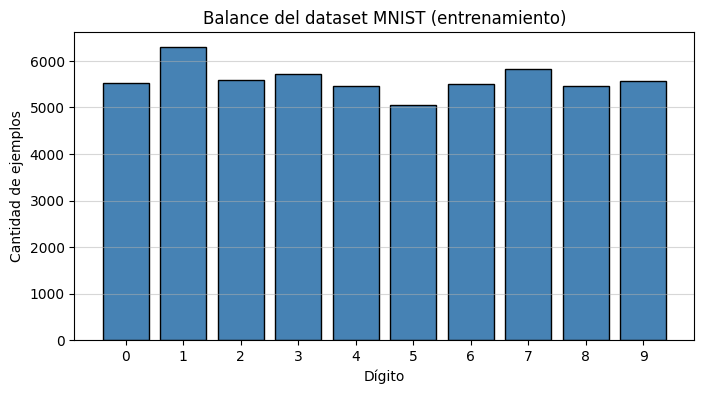

In [ ]:
import pandas as pd

# Contar ejemplos por clase
balance = pd.Series(y).value_counts().sort_index()
print("Ejemplos por clase:")
print(balance)

# Graficar balance
pyplot.figure(figsize=(8, 4))
pyplot.bar(balance.index, balance.values, color='steelblue', edgecolor='black')
pyplot.xlabel('Dígito')
pyplot.ylabel('Cantidad de ejemplos')
pyplot.title('Balance del dataset MNIST (entrenamiento)')
pyplot.xticks(range(10))
pyplot.grid(axis='y', alpha=0.5)
pyplot.show()

## Visualización de datos

In [ ]:
def displayData(X, example_width=None, figsize=(10, 10)):
    """
    Muestra datos 2D almacenados en X en una cuadrícula apropiada.
    Adaptado para MNIST: imágenes de 28x28 píxeles.
    """
    # Calcula filas, columnas
    if X.ndim == 2:
        m, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m = 1
        X = X[None]  # Promocionar a una matriz bidimensional
    else:
        raise IndexError('La entrada X debe ser 1 o 2 dimensional.')

    example_width = example_width or int(np.round(np.sqrt(n)))
    example_height = int(n / example_width)  # 28

    # Calcula el numero de elementos a mostrar
    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = pyplot.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.025)

    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        # Cambio principal: reshape a (28, 28) y order='C' en lugar de 'F'
        ax.imshow(X[i].reshape(example_height, example_width, order='C'),
                  cmap='Greys', extent=[0, 1, 0, 1])
        ax.axis('off')

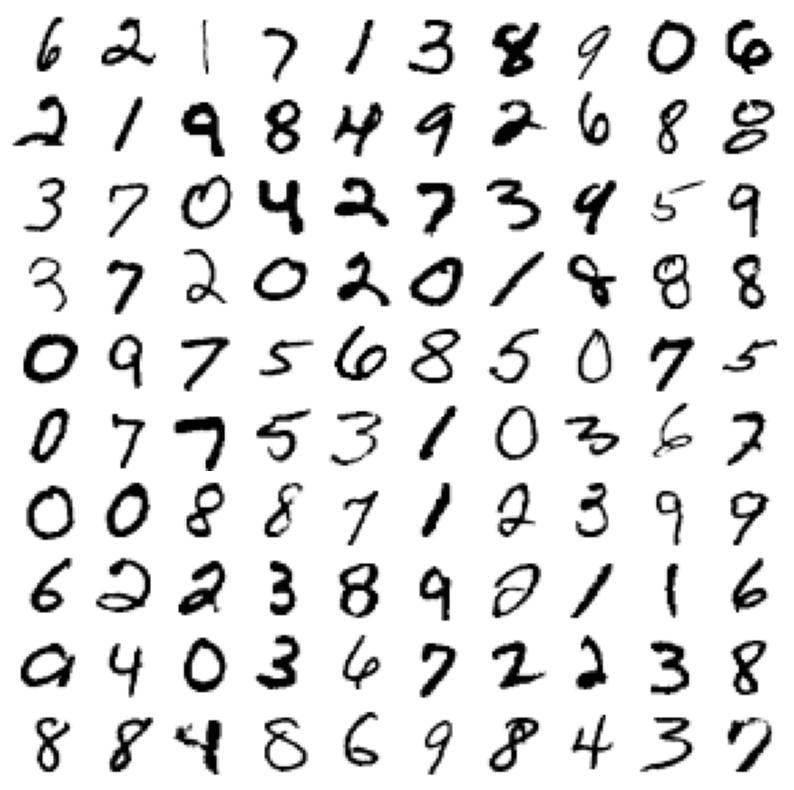

In [ ]:
# Selecciona aleatoriamente 100 puntos de datos para mostrar
rand_indices = np.random.choice(m, 100, replace=False)
sel = X[rand_indices, :]

displayData(sel)

## Funciones para el procesamiento

In [ ]:
def sigmoid(z):
    """
    Calcula la sigmoide de z.
    """
    return 1.0 / (1.0 + np.exp(-z))

In [ ]:
def lrCostFunction(theta, X, y, lambda_):
    """
    Calcula el costo de usando theta como parámetro para la regresión logística regularizada y
    el gradiente del costo w.r.t. a los parámetros.

    Parametros
    ----------
    theta : array_like
        Parametro theta de la regresion logistica. Vector de la forma(shape) (n, ). n es el numero de caracteristicas
        incluida la intercepcion

    X : array_like
        Dataset con la forma(shape) (m x n). m es el numero de ejemplos, y n es el numero de
        caracteristicas (incluida la intercepcion).

    y : array_like
        El conjunto de etiquetas. Un vector con la forma (shape) (m, ). m es el numero de ejemplos

    lambda_ : float
        Parametro de regularización.

    Devuelve
    -------
    J : float
        El valor calculado para la funcion de costo regularizada.

    grad : array_like
        Un vector de la forma (shape) (n, ) que es el gradiente de la
        función de costo con respecto a theta, en los valores actuales de theta.
    """
    m = y.size

    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    temp = theta.copy()  # ← único cambio recomendado: .copy() para no modificar theta original
    temp[0] = 0

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * (h - y).dot(X)
    grad = grad + (lambda_ / m) * temp

    return J, grad

## Clasificación one vs all

In [ ]:
def oneVsAll(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    costos = []           # costo final por clase
    historial = {}        # historial de costos por iteración para cada clase ← NUEVO

    for c in np.arange(num_labels):
        print(f'Entrenando clasificador para dígito {c}...')
        initial_theta = np.zeros(n + 1)
        options = {'maxiter': 50}

        historial_c = []  # historial de esta clase

        # callback se llama en cada iteración con el theta actual
        def callback(theta_actual):
            J, _ = lrCostFunction(theta_actual, X, (y == c), lambda_)
            historial_c.append(J)

        res = optimize.minimize(lrCostFunction,
                                initial_theta,
                                (X, (y == c), lambda_),
                                jac=True,
                                method='CG',
                                callback=callback,   # ← NUEVO
                                options=options)

        all_theta[c] = res.x
        costos.append(res.fun)
        historial[c] = historial_c   # ← guardar historial de esta clase
        print(f'  ✓ Dígito {c} completado. Costo final: {res.fun:.4f}')

    return all_theta, costos, historial  # ← retorna también el historial

In [ ]:
lambda_ = 0.1
all_theta, costos, historial = oneVsAll(X, y, num_labels, lambda_)

Entrenando clasificador para dígito 0...
  ✓ Dígito 0 completado. Costo final: 0.0218
Entrenando clasificador para dígito 1...
  ✓ Dígito 1 completado. Costo final: 0.0222
Entrenando clasificador para dígito 2...
  ✓ Dígito 2 completado. Costo final: 0.0669
Entrenando clasificador para dígito 3...
  ✓ Dígito 3 completado. Costo final: 0.0777
Entrenando clasificador para dígito 4...
  ✓ Dígito 4 completado. Costo final: 0.0493
Entrenando clasificador para dígito 5...
  ✓ Dígito 5 completado. Costo final: 0.0843
Entrenando clasificador para dígito 6...
  ✓ Dígito 6 completado. Costo final: 0.0356
Entrenando clasificador para dígito 7...
  ✓ Dígito 7 completado. Costo final: 0.0466
Entrenando clasificador para dígito 8...
  ✓ Dígito 8 completado. Costo final: 0.1129
Entrenando clasificador para dígito 9...
  ✓ Dígito 9 completado. Costo final: 0.0982


## Predicción One vs All

In [ ]:
def predictOneVsAll(all_theta, X):
    """
    Devuelve un vector de predicciones para cada ejemplo en la matriz X.
    Tenga en cuenta que X contiene los ejemplos en filas.
    all_theta es una matriz donde la i-ésima fila es un vector theta de regresión logística entrenada para la i-ésima clase.
    Debe establecer p en un vector de valores de 0..K-1 (por ejemplo, p = [0, 2, 0, 1]
    predice clases 0, 2, 0, 1 para 4 ejemplos).

    Parametros
    ----------
    all_theta : array_like
        Parámetros entrenados para regresión logística por cada clase.
        Matriz de forma (K x n+1) donde K es número de clases
        y n es número de features sin el bias.

    X : array_like
        Puntos de datos para predecir sus etiquetas. Matriz de forma
        (m x n) donde m es número de ejemplos y n es número de features
        sin el bias. El bias se agrega dentro de esta función.

    Devuelve
    -------
    p : array_like
        Predicciones para cada ejemplo en X. Vector de forma (m, ).
    """
    m = X.shape[0]
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Agrega columna de unos (bias) a X
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    # Calcula la probabilidad para cada clase y toma la de mayor valor
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis=1)

    return p

(56000, 784)
Precisión del conjunto de entrenamiento: 92.32%
Precisión del conjunto de testeo:        91.80%

Forma XPrueba original: (12, 784)
Forma XPrueba con bias: (12, 785)

Predicciones: [9 9 8 9 2 2 4 7 5 4 3 2]
Etiquetas reales: [9 9 8 7 2 2 4 7 5 4 3 2]


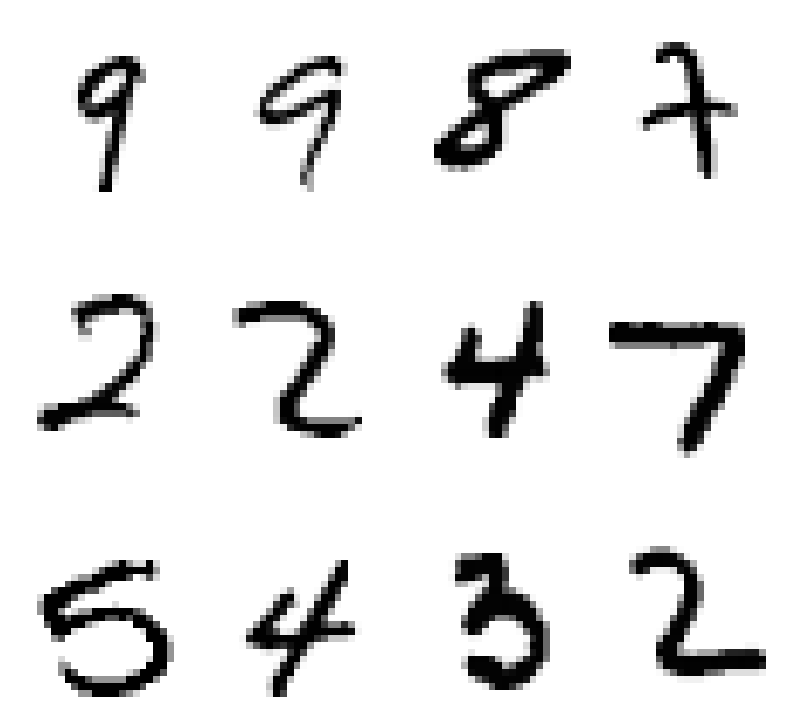

In [ ]:
print(X.shape)  # (56000, 784)

# Precisión sobre el conjunto de entrenamiento
pred = predictOneVsAll(all_theta, X)
print('Precisión del conjunto de entrenamiento: {:.2f}%'.format(np.mean(pred == y) * 100))

# Precisión sobre el conjunto de TESTEO (datos nunca vistos)
pred_test = predictOneVsAll(all_theta, X_test)
print('Precisión del conjunto de testeo:        {:.2f}%'.format(np.mean(pred_test == y_test) * 100))

# ---- Prueba visual con 12 ejemplos ----
XPrueba = X[2001:2013, :].copy()
print(f'\nForma XPrueba original: {XPrueba.shape}')  # (12, 784)

# Agrega bias
XPrueba_bias = np.concatenate([np.ones((12, 1)), XPrueba], axis=1)
print(f'Forma XPrueba con bias: {XPrueba_bias.shape}')  # (12, 785)

# Predicciones
p = np.argmax(sigmoid(XPrueba_bias.dot(all_theta.T)), axis=1)
print(f'\nPredicciones: {p}')
print(f'Etiquetas reales: {y[2001:2013]}')

# Mostrar las imágenes
displayData(X[2001:2013, :])

## Testeo

Forma X_test: (14000, 784)
Forma y_test: (14000,)

Precisión del conjunto de testeo: 91.80%

Forma XPrueba original: (12, 784)
Forma XPrueba con bias: (12, 785)

Predicciones:    [7 3 1 1 2 5 9 3 8 1 6 6]
Etiquetas reales:[7 3 1 1 2 5 9 8 8 1 6 6]
Aciertos en muestra visual: 11/12


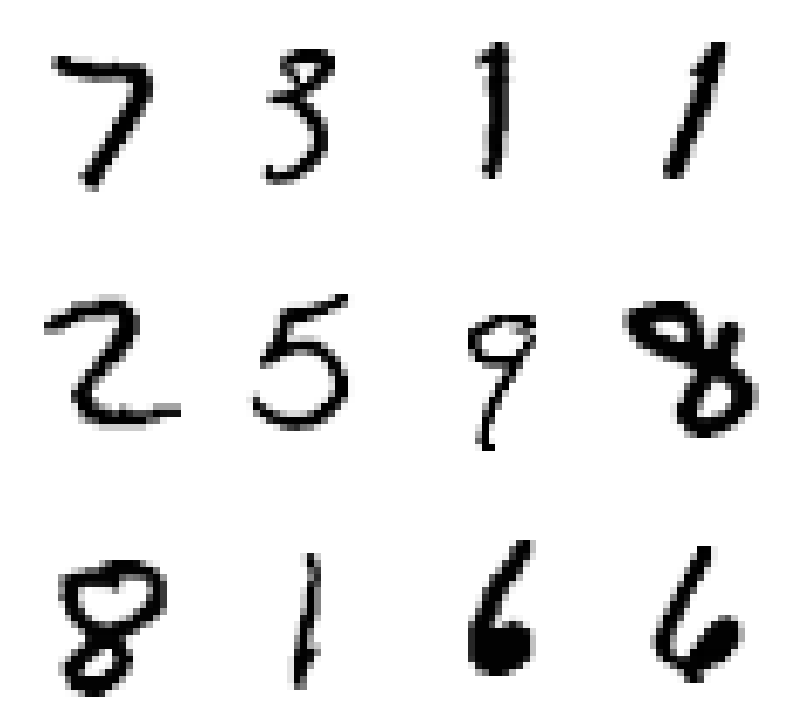

In [ ]:
# ---- Testeo con el 20% de datos separados ----
print(f'Forma X_test: {X_test.shape}')   # (14000, 784)
print(f'Forma y_test: {y_test.shape}')   # (14000,)

# Precisión sobre el conjunto de testeo
pred_test = predictOneVsAll(all_theta, X_test)
print('\nPrecisión del conjunto de testeo: {:.2f}%'.format(np.mean(pred_test == y_test) * 100))

# ---- Prueba visual con 12 ejemplos del conjunto de TESTEO ----
XPrueba = X_test[0:12, :].copy()
print(f'\nForma XPrueba original: {XPrueba.shape}')   # (12, 784)

# Agrega bias
XPrueba_bias = np.concatenate([np.ones((12, 1)), XPrueba], axis=1)
print(f'Forma XPrueba con bias: {XPrueba_bias.shape}') # (12, 785)

# Predicciones
p = np.argmax(sigmoid(XPrueba_bias.dot(all_theta.T)), axis=1)
print(f'\nPredicciones:    {p}')
print(f'Etiquetas reales:{y_test[0:12]}')

# Verificar cuántas acertó de esas 12
aciertos = np.sum(p == y_test[0:12])
print(f'Aciertos en muestra visual: {aciertos}/12')

# Mostrar las imágenes del conjunto de testeo
displayData(X_test[0:12, :])

## Gráfico de costo

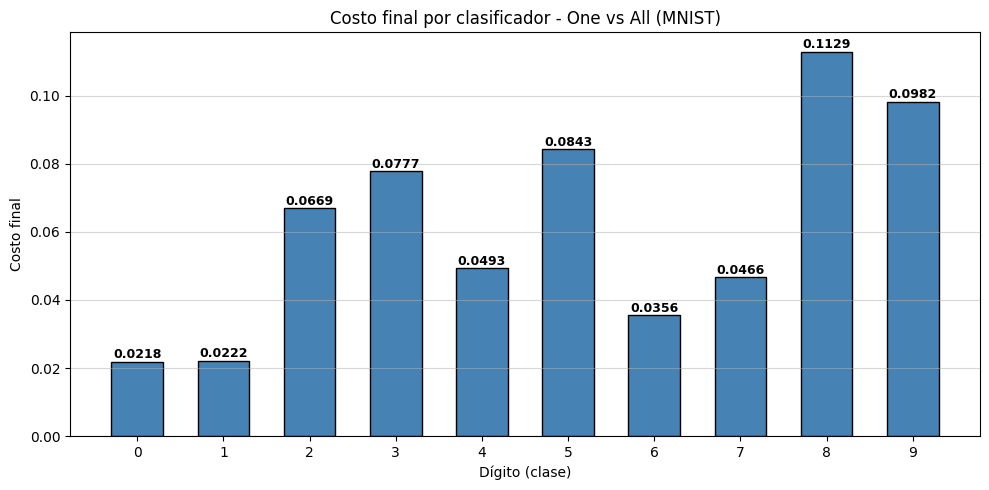

In [ ]:
# ---- Gráfica de costo por clasificador (barras) ----
pyplot.figure(figsize=(10, 5))
barras = pyplot.bar(range(num_labels), costos, color='steelblue', edgecolor='black', width=0.6)

# Anotar valor encima de cada barra
for i, (barra, c) in enumerate(zip(barras, costos)):
    pyplot.text(barra.get_x() + barra.get_width()/2,
                c + 0.001, f'{c:.4f}', ha='center', fontsize=9, fontweight='bold')

pyplot.xlabel('Dígito (clase)')
pyplot.ylabel('Costo final')
pyplot.title('Costo final por clasificador - One vs All (MNIST)')
pyplot.xticks(range(10))
pyplot.grid(axis='y', alpha=0.5)
pyplot.tight_layout()
pyplot.show()

## Gráfica de Precisión entrenamiento vs testeo

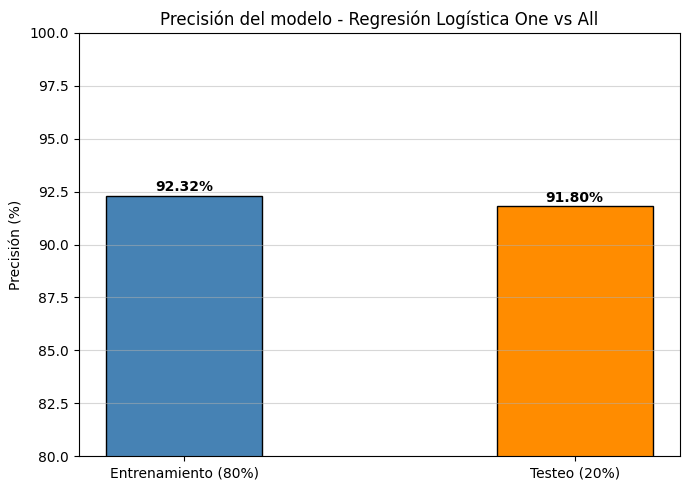

Precisión entrenamiento: 92.32%
Precisión testeo:        91.80%


In [ ]:
# ---- Gráfica de precisión ----
precision_train = np.mean(predictOneVsAll(all_theta, X) == y) * 100
precision_test  = np.mean(predictOneVsAll(all_theta, X_test) == y_test) * 100

pyplot.figure(figsize=(7, 5))
barras = pyplot.bar(
    ['Entrenamiento (80%)', 'Testeo (20%)'],
    [precision_train, precision_test],
    color=['steelblue', 'darkorange'],
    edgecolor='black', width=0.4
)
for barra, val in zip(barras, [precision_train, precision_test]):
    pyplot.text(barra.get_x() + barra.get_width()/2,
                val + 0.2, f'{val:.2f}%', ha='center', fontweight='bold')
pyplot.ylabel('Precisión (%)')
pyplot.title('Precisión del modelo - Regresión Logística One vs All')
pyplot.ylim([80, 100])
pyplot.grid(axis='y', alpha=0.5)
pyplot.tight_layout()
pyplot.show()

print(f'Precisión entrenamiento: {precision_train:.2f}%')
print(f'Precisión testeo:        {precision_test:.2f}%')

## Predicho vs Real por cada dígito

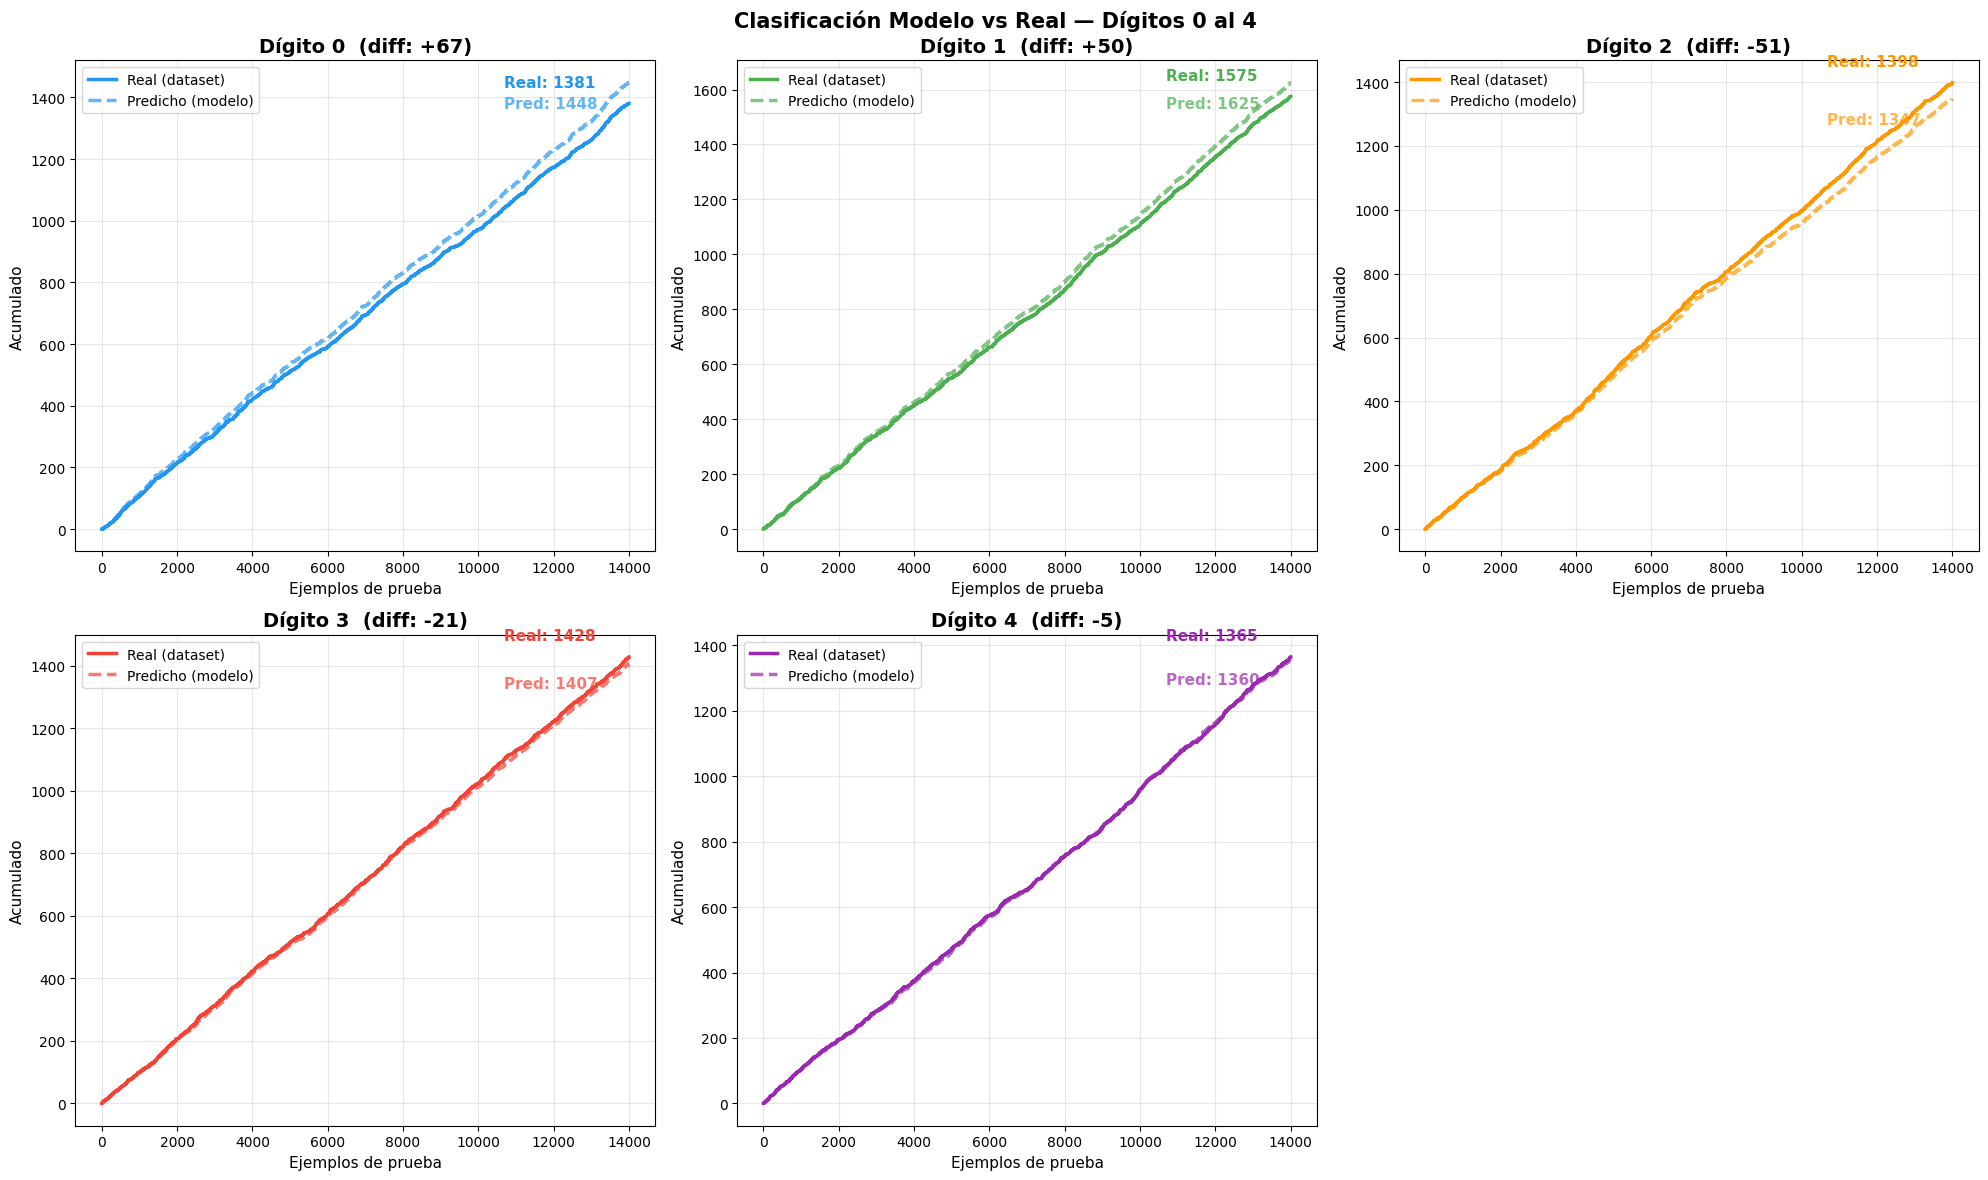

In [ ]:
# ---- Bloque 1: Dígitos 0 al 4 ----
clases  = [f'Dígito {i}' for i in range(5)]
colores = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']

fig, axes = pyplot.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, (clase, color) in enumerate(zip(clases, colores)):
    real_c        = (y_test == i).astype(int)
    predicho_c    = (pred_test == i).astype(int)
    real_acum     = np.cumsum(real_c)
    predicho_acum = np.cumsum(predicho_c)
    x = np.arange(len(y_test))

    axes[i].plot(x, real_acum,     lw=2.5, label='Real (dataset)',    color=color, linestyle='-')
    axes[i].plot(x, predicho_acum, lw=2.5, label='Predicho (modelo)', color=color, linestyle='--', alpha=0.7)

    axes[i].annotate(f'Real: {real_acum[-1]}',
                     xy=(len(y_test)-1, real_acum[-1]),
                     xytext=(-90, 12), textcoords='offset points',
                     color=color, fontweight='bold', fontsize=11)
    axes[i].annotate(f'Pred: {predicho_acum[-1]}',
                     xy=(len(y_test)-1, predicho_acum[-1]),
                     xytext=(-90, -18), textcoords='offset points',
                     color=color, fontweight='bold', fontsize=11, alpha=0.7)

    diff = predicho_acum[-1] - real_acum[-1]
    signo = '+' if diff >= 0 else ''
    axes[i].set_title(f'{clase}  (diff: {signo}{diff})', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Ejemplos de prueba', fontsize=11)
    axes[i].set_ylabel('Acumulado', fontsize=11)
    axes[i].legend(fontsize=10)
    axes[i].grid(True, alpha=0.3)

# Ocultar el subplot vacío (posición 5, índice 5)
axes[5].set_visible(False)

pyplot.suptitle('Clasificación Modelo vs Real — Dígitos 0 al 4',
                fontsize=15, fontweight='bold')
pyplot.tight_layout()
pyplot.show()

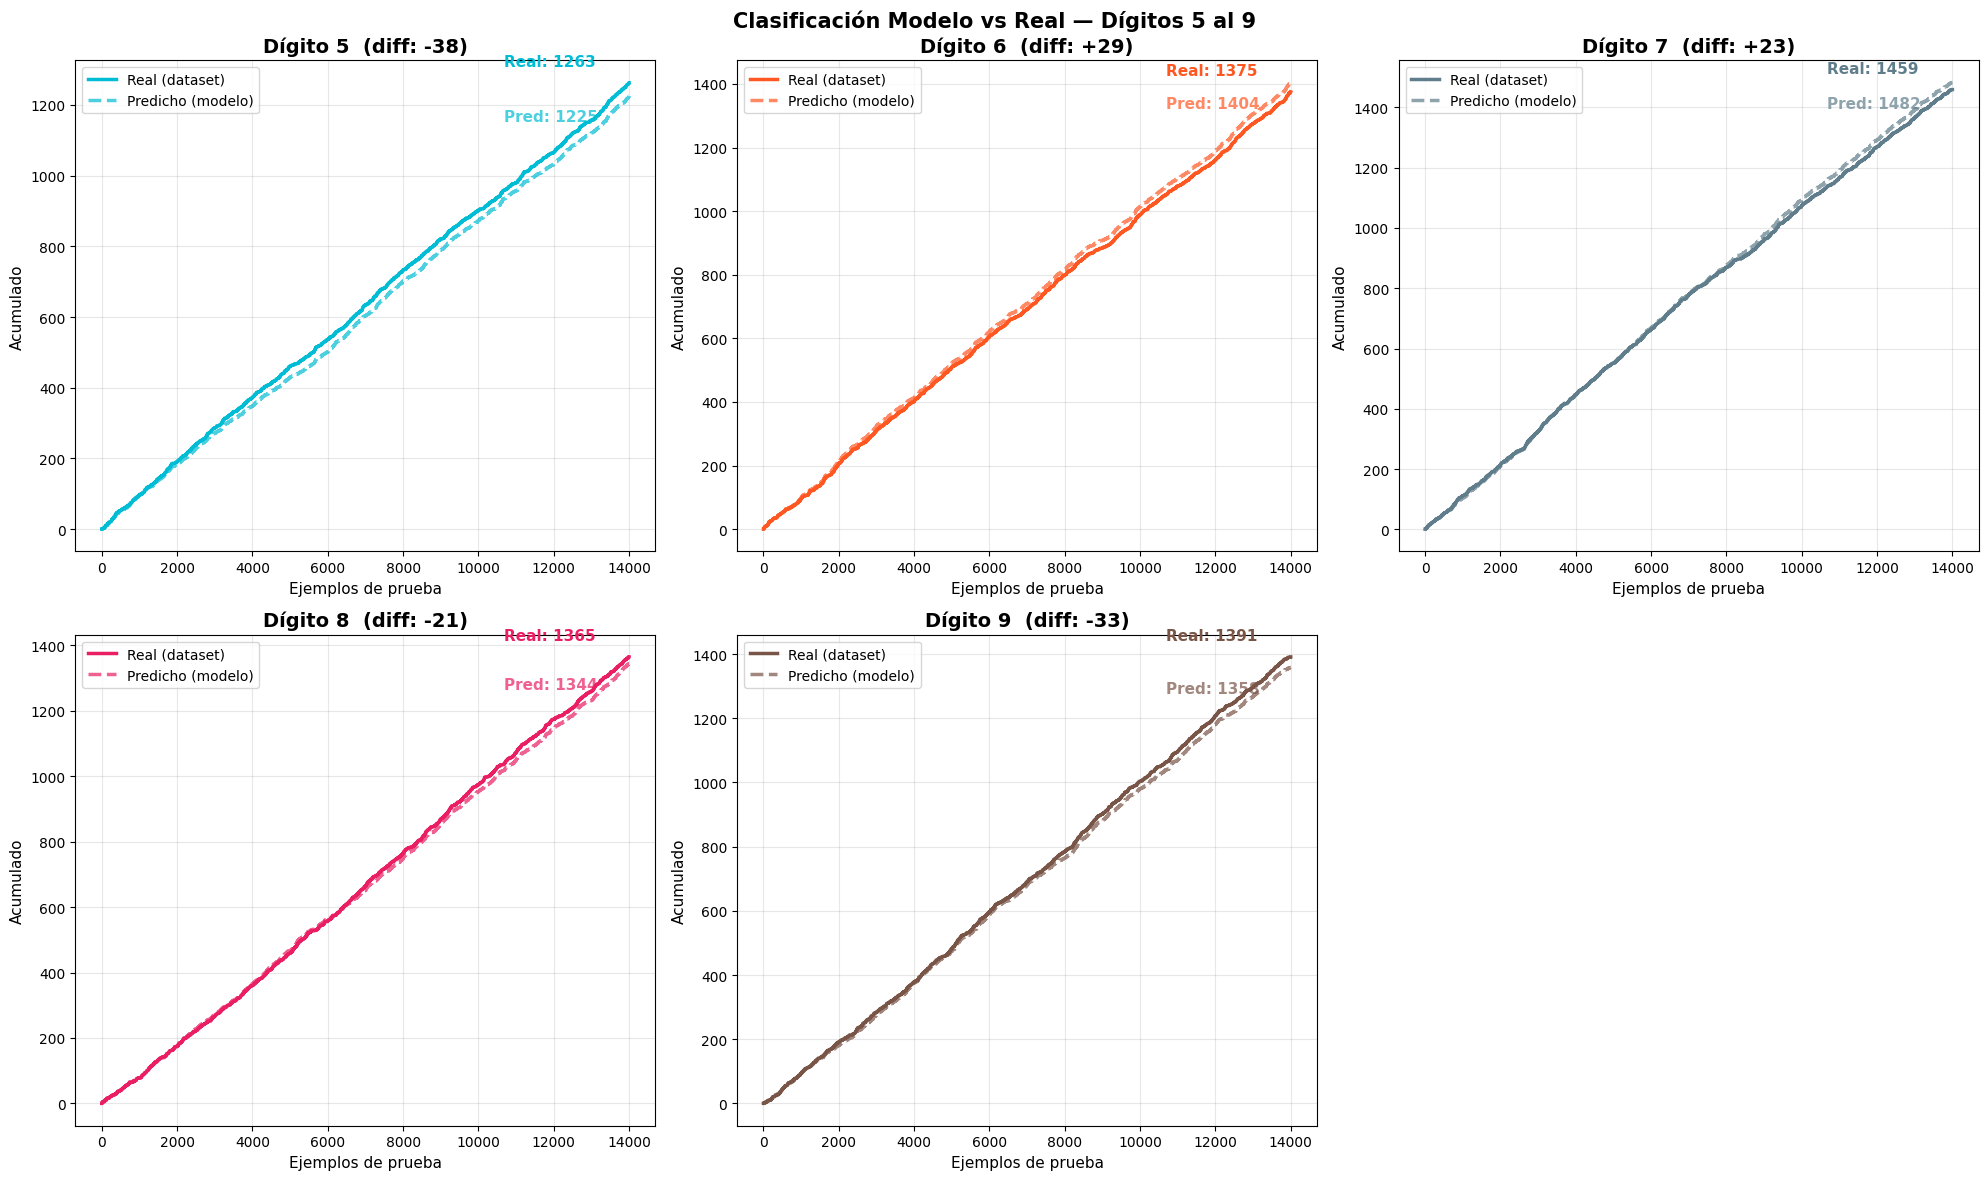

In [ ]:
# ---- Bloque 2: Dígitos 5 al 9 ----
clases  = [f'Dígito {i}' for i in range(5, 10)]
colores = ['#00BCD4', '#FF5722', '#607D8B', '#E91E63', '#795548']

fig, axes = pyplot.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for idx, (i, clase, color) in enumerate(zip(range(5, 10), clases, colores)):
    real_c        = (y_test == i).astype(int)
    predicho_c    = (pred_test == i).astype(int)
    real_acum     = np.cumsum(real_c)
    predicho_acum = np.cumsum(predicho_c)
    x = np.arange(len(y_test))

    axes[idx].plot(x, real_acum,     lw=2.5, label='Real (dataset)',    color=color, linestyle='-')
    axes[idx].plot(x, predicho_acum, lw=2.5, label='Predicho (modelo)', color=color, linestyle='--', alpha=0.7)

    axes[idx].annotate(f'Real: {real_acum[-1]}',
                       xy=(len(y_test)-1, real_acum[-1]),
                       xytext=(-90, 12), textcoords='offset points',
                       color=color, fontweight='bold', fontsize=11)
    axes[idx].annotate(f'Pred: {predicho_acum[-1]}',
                       xy=(len(y_test)-1, predicho_acum[-1]),
                       xytext=(-90, -18), textcoords='offset points',
                       color=color, fontweight='bold', fontsize=11, alpha=0.7)

    diff = predicho_acum[-1] - real_acum[-1]
    signo = '+' if diff >= 0 else ''
    axes[idx].set_title(f'{clase}  (diff: {signo}{diff})', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Ejemplos de prueba', fontsize=11)
    axes[idx].set_ylabel('Acumulado', fontsize=11)
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3)

# Ocultar el subplot vacío (posición 5, índice 5)
axes[5].set_visible(False)

pyplot.suptitle('Clasificación Modelo vs Real — Dígitos 5 al 9',
                fontsize=15, fontweight='bold')
pyplot.tight_layout()
pyplot.show()

## Gráfico de Descenso de Gradiente por dígito

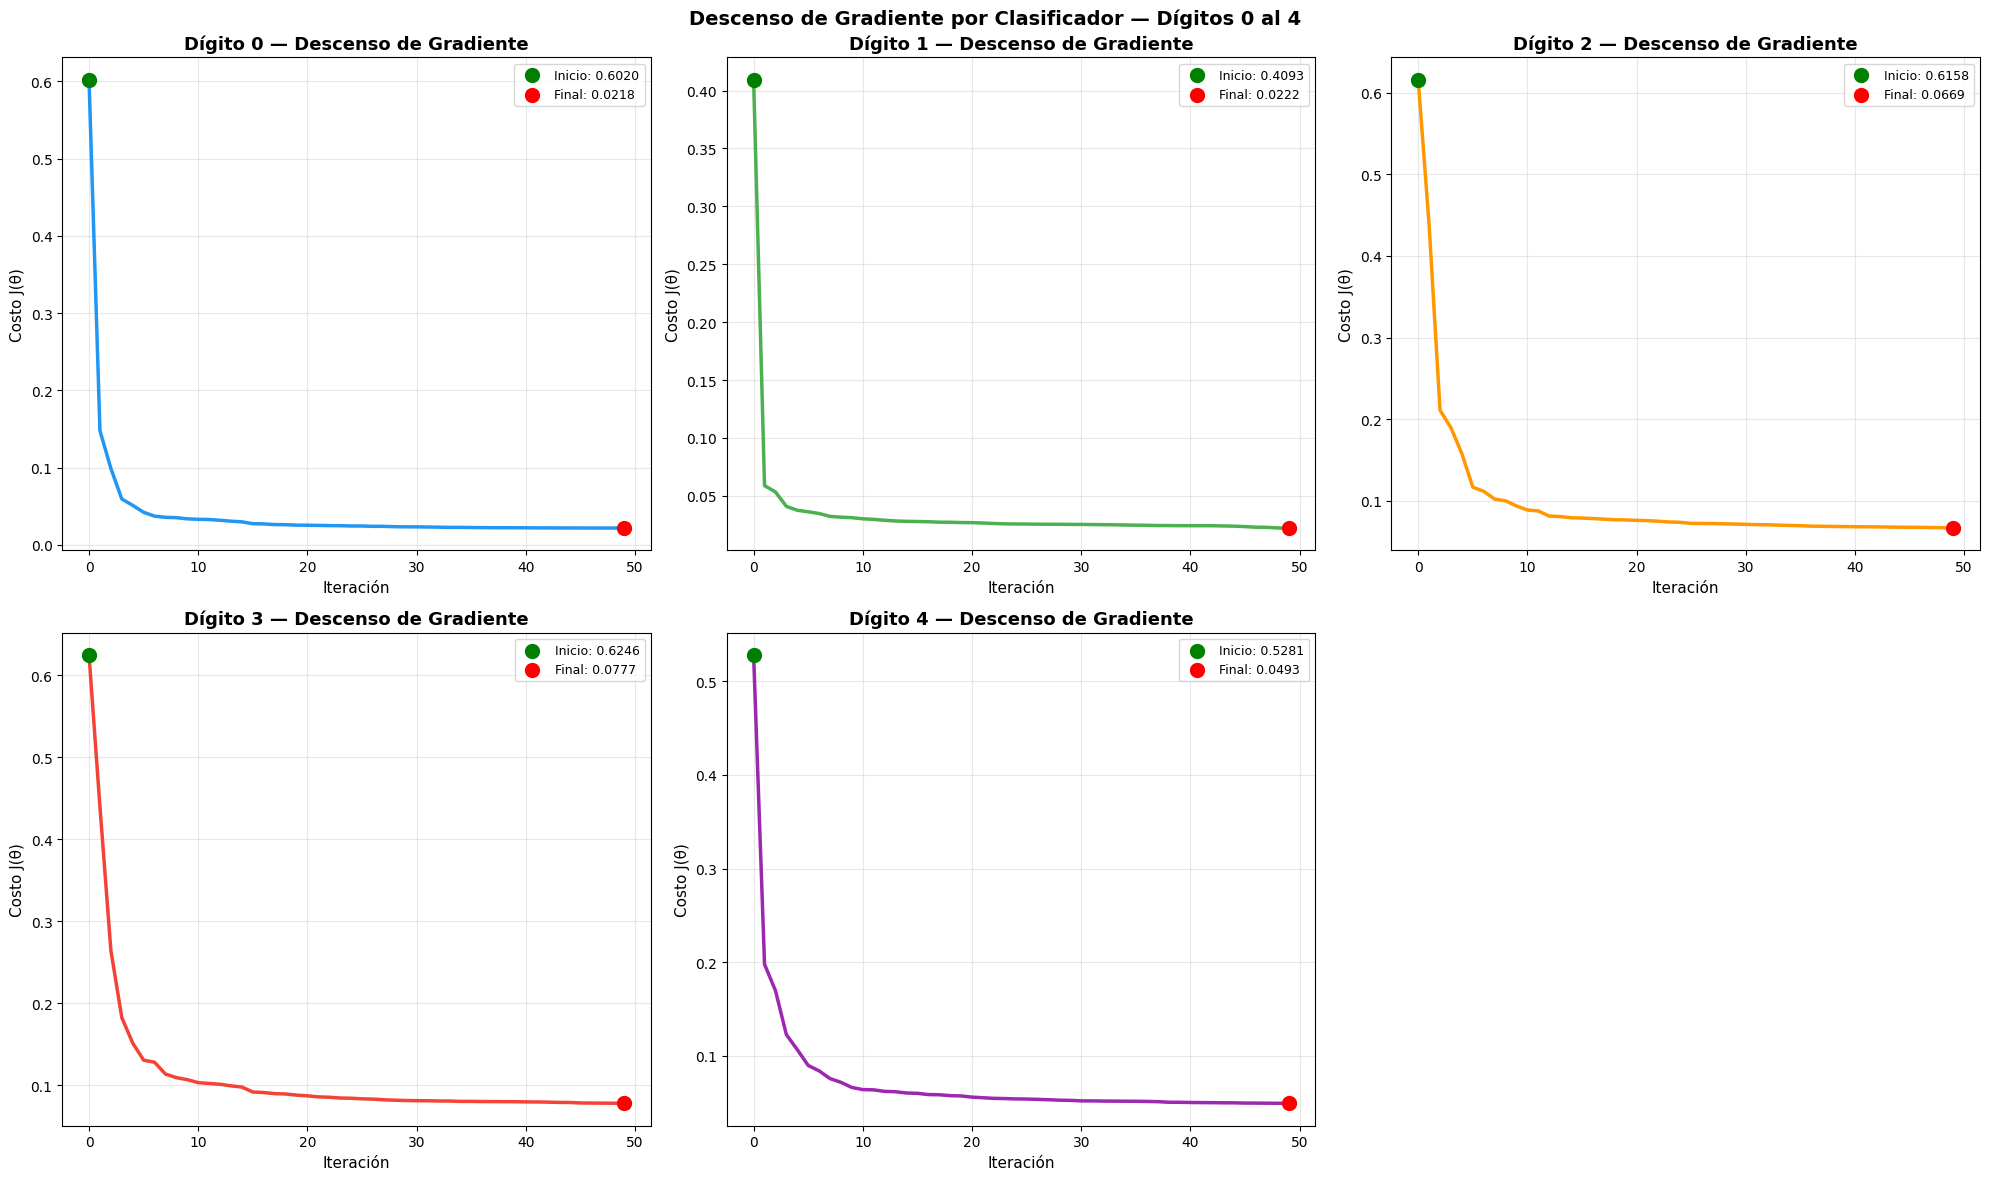

In [ ]:
# ---- Descenso de Gradiente por dígito (0-4) ----
colores = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0',
           '#00BCD4', '#FF5722', '#607D8B', '#E91E63', '#795548']

fig, axes = pyplot.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i in range(5):
    ax = axes[i]
    iteraciones = range(len(historial[i]))
    ax.plot(iteraciones, historial[i], color=colores[i], lw=2.5)
    ax.scatter([0], [historial[i][0]], color='green',  s=100, zorder=5, label=f'Inicio: {historial[i][0]:.4f}')
    ax.scatter([len(historial[i])-1], [historial[i][-1]], color='red', s=100, zorder=5, label=f'Final: {historial[i][-1]:.4f}')
    ax.set_title(f'Dígito {i} — Descenso de Gradiente', fontsize=13, fontweight='bold')
    ax.set_xlabel('Iteración', fontsize=11)
    ax.set_ylabel('Costo J(θ)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[5].set_visible(False)
pyplot.suptitle('Descenso de Gradiente por Clasificador — Dígitos 0 al 4',
                fontsize=14, fontweight='bold')
pyplot.tight_layout()
pyplot.show()

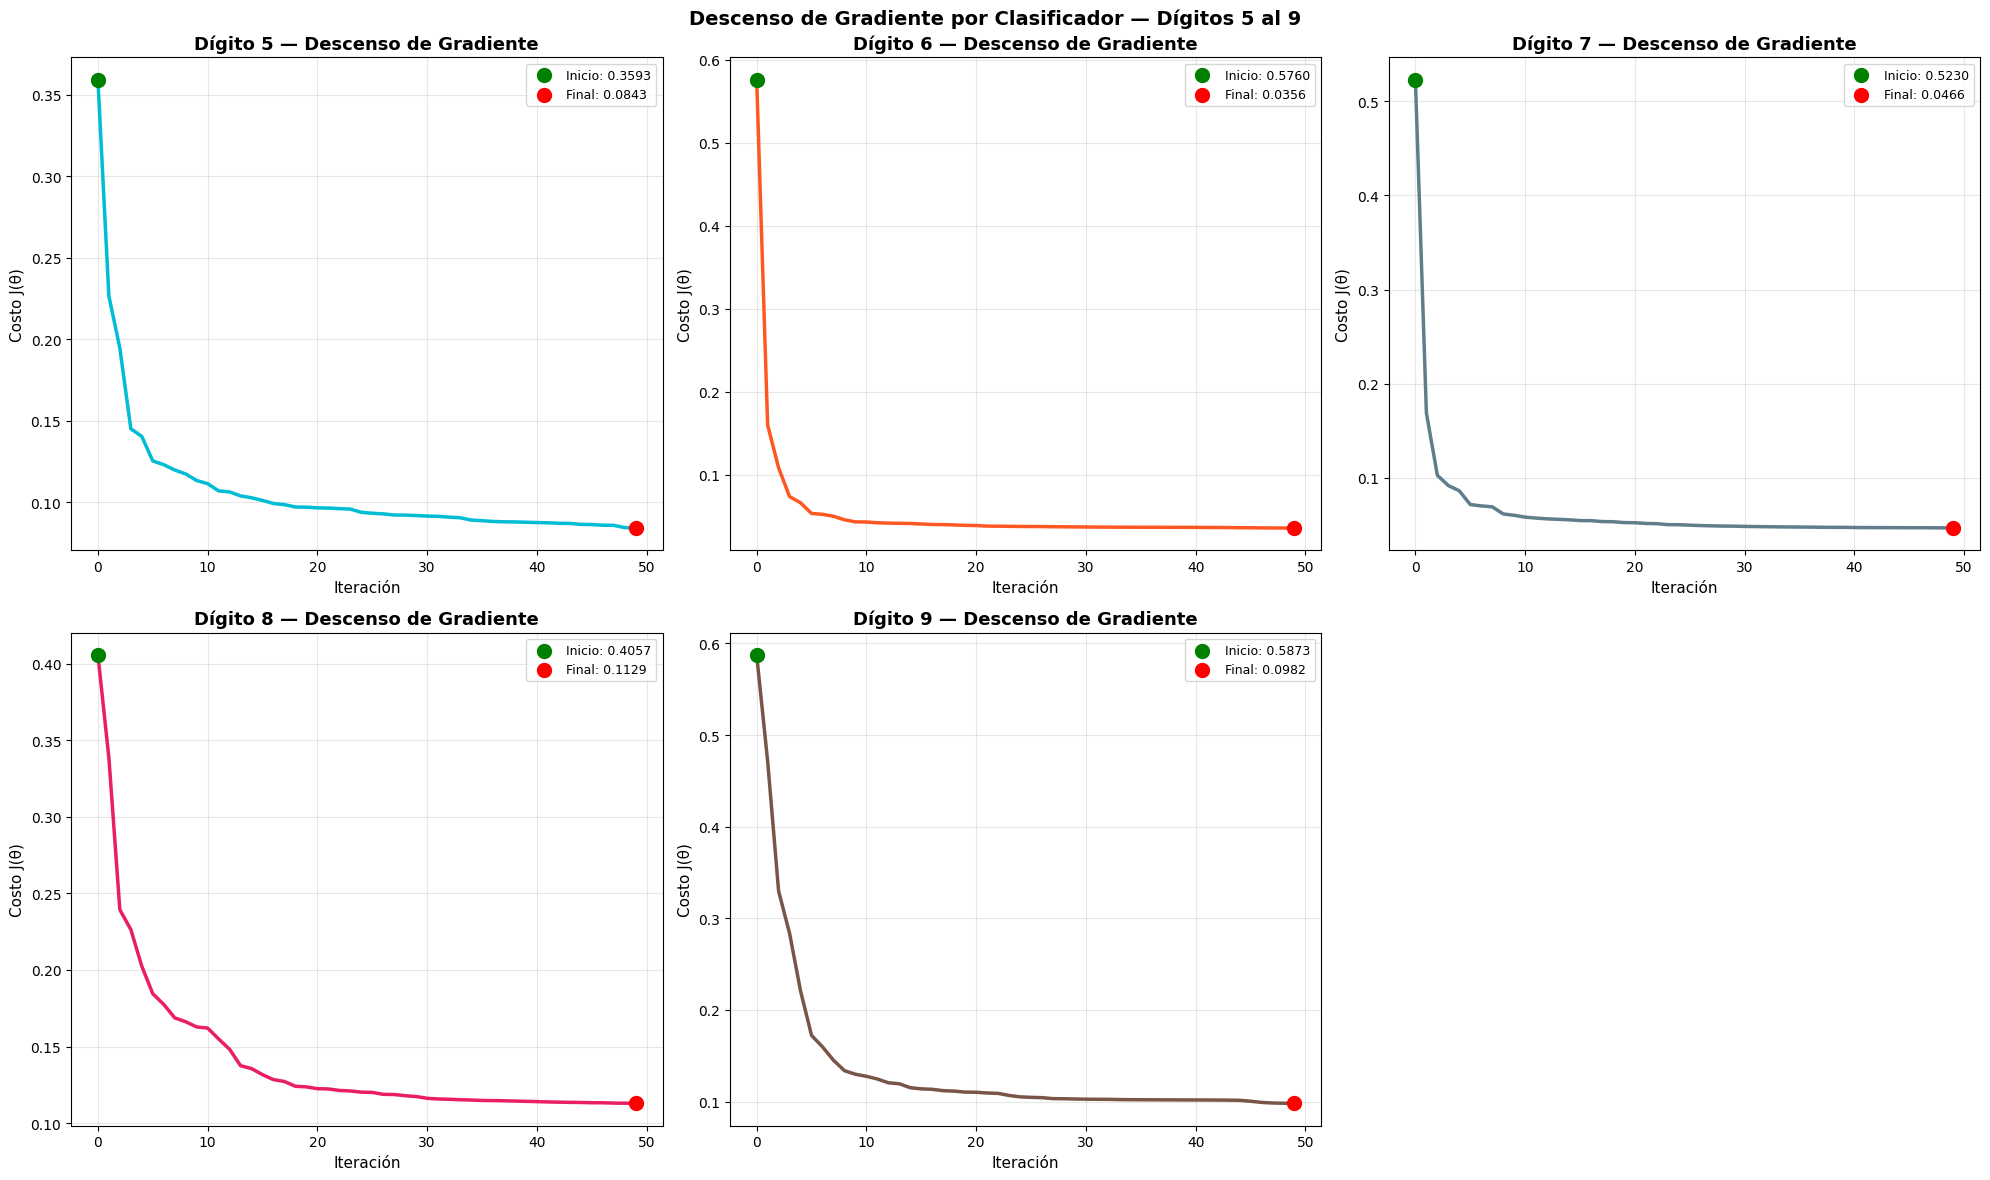

In [ ]:
# ---- Descenso de Gradiente por dígito (5-9) ----
fig, axes = pyplot.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for idx, i in enumerate(range(5, 10)):
    ax = axes[idx]
    iteraciones = range(len(historial[i]))
    ax.plot(iteraciones, historial[i], color=colores[i], lw=2.5)
    ax.scatter([0], [historial[i][0]], color='green',  s=100, zorder=5, label=f'Inicio: {historial[i][0]:.4f}')
    ax.scatter([len(historial[i])-1], [historial[i][-1]], color='red', s=100, zorder=5, label=f'Final: {historial[i][-1]:.4f}')
    ax.set_title(f'Dígito {i} — Descenso de Gradiente', fontsize=13, fontweight='bold')
    ax.set_xlabel('Iteración', fontsize=11)
    ax.set_ylabel('Costo J(θ)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[5].set_visible(False)
pyplot.suptitle('Descenso de Gradiente por Clasificador — Dígitos 5 al 9',
                fontsize=14, fontweight='bold')
pyplot.tight_layout()
pyplot.show()